# LangChain快速入门

## 准备工作

首先，要使用LangChain必须先安装依赖，命令如下：
```
uv add langchain
```

LangChain支持各种不同的模型，而且提供了对应的兼容SDK，不过也都需要安装对应依赖，你可以按需添加：
```
# 集成 DeepSeek
uv add langchain-deepseek

# 集成 OpenAI
uv add langchain-openai

# 集成 Anthropic
uv add langchain-anthropic
```

接下来就可以开发Agent了，基本步骤如下：
1. 加载环境变量（已经写到环境变量里，就忽略）
2. 定义工具
3. 定义Agent
4. 调用Agent

In [1]:
from langchain.tools import tool
from langchain.agents import create_agent

# 1. 定义工具
@tool
def getWather(location: str) -> str:
    """ Get the weather in a given location. """
    return f"Current weather in {location} is sunny"

# 2. 创建Agent
agent = create_agent(
    model="deepseek-flash",
    tools = [getWather],
    system_prompt="You are a helpful assistant",
    # response_format 添加结构化输出
    # state_schema
)

# 3. 调用大模型
print("🚀正在调用大模型...")
response = agent.invoke(
    {"messages":[{"role": "user", "content": "杭州今天天气如何"}]}
)

print(response["messages"][-1].content_blocks)

🚀正在调用大模型...
[{'type': 'reasoning', 'reasoning': 'Call result says "Current weather in 杭州 is sunny". Need respond in Chinese. Could say 杭州今天天气晴朗。 Maybe mention only current info. We don\'t have temp. Let\'s answer.'}, {'type': 'text', 'text': '杭州今天天气晴朗 ☀️。请注意，我这里只能查到当前天气为晴，暂时没有气温等更详细的信息。'}]


In [40]:
for message in response['messages']:
    print(message.model_dump_json(indent=2))
    print("---------------------------------")

{
  "content": "杭州今天天气如何",
  "additional_kwargs": {},
  "response_metadata": {},
  "type": "human",
  "name": null,
  "id": "595e486d-c2b9-4238-b3c2-3e9465461576"
}
---------------------------------
{
  "content": "",
  "additional_kwargs": {
    "refusal": null,
    "reasoning_content": "The user is asking about the weather in Hangzhou today. I should use the getWather tool."
  },
  "response_metadata": {
    "token_usage": {
      "completion_tokens": 60,
      "prompt_tokens": 300,
      "total_tokens": 360,
      "completion_tokens_details": {
        "accepted_prediction_tokens": null,
        "audio_tokens": null,
        "reasoning_tokens": 21,
        "rejected_prediction_tokens": null,
        "text_tokens": null
      },
      "prompt_tokens_details": {
        "audio_tokens": null,
        "cache_write_tokens": null,
        "cached_tokens": 128,
        "image_tokens": null,
        "text_tokens": null
      },
      "prompt_cache_hit_tokens": 128,
      "prompt_cache_miss_

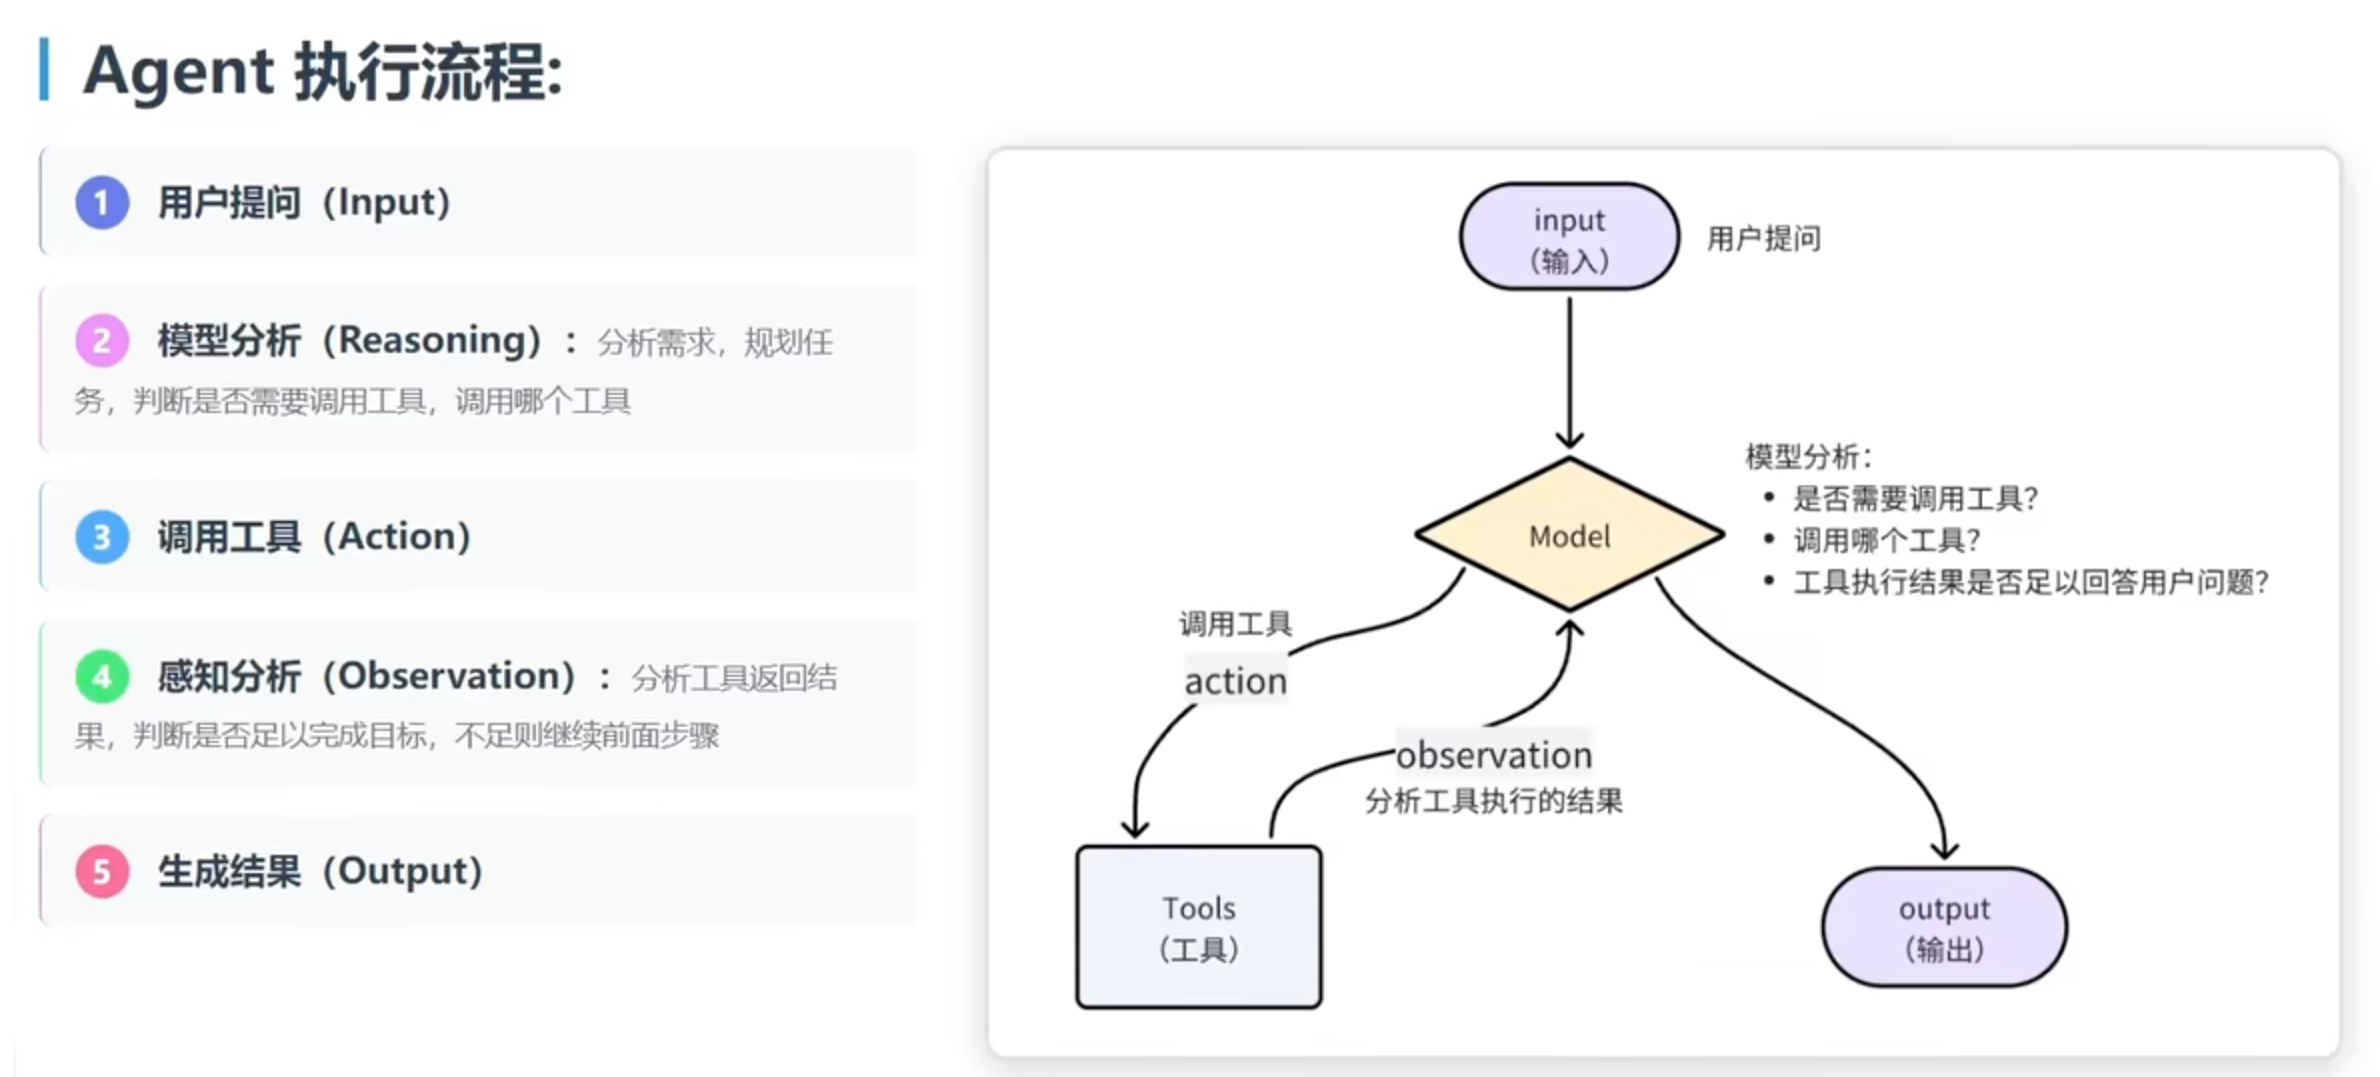

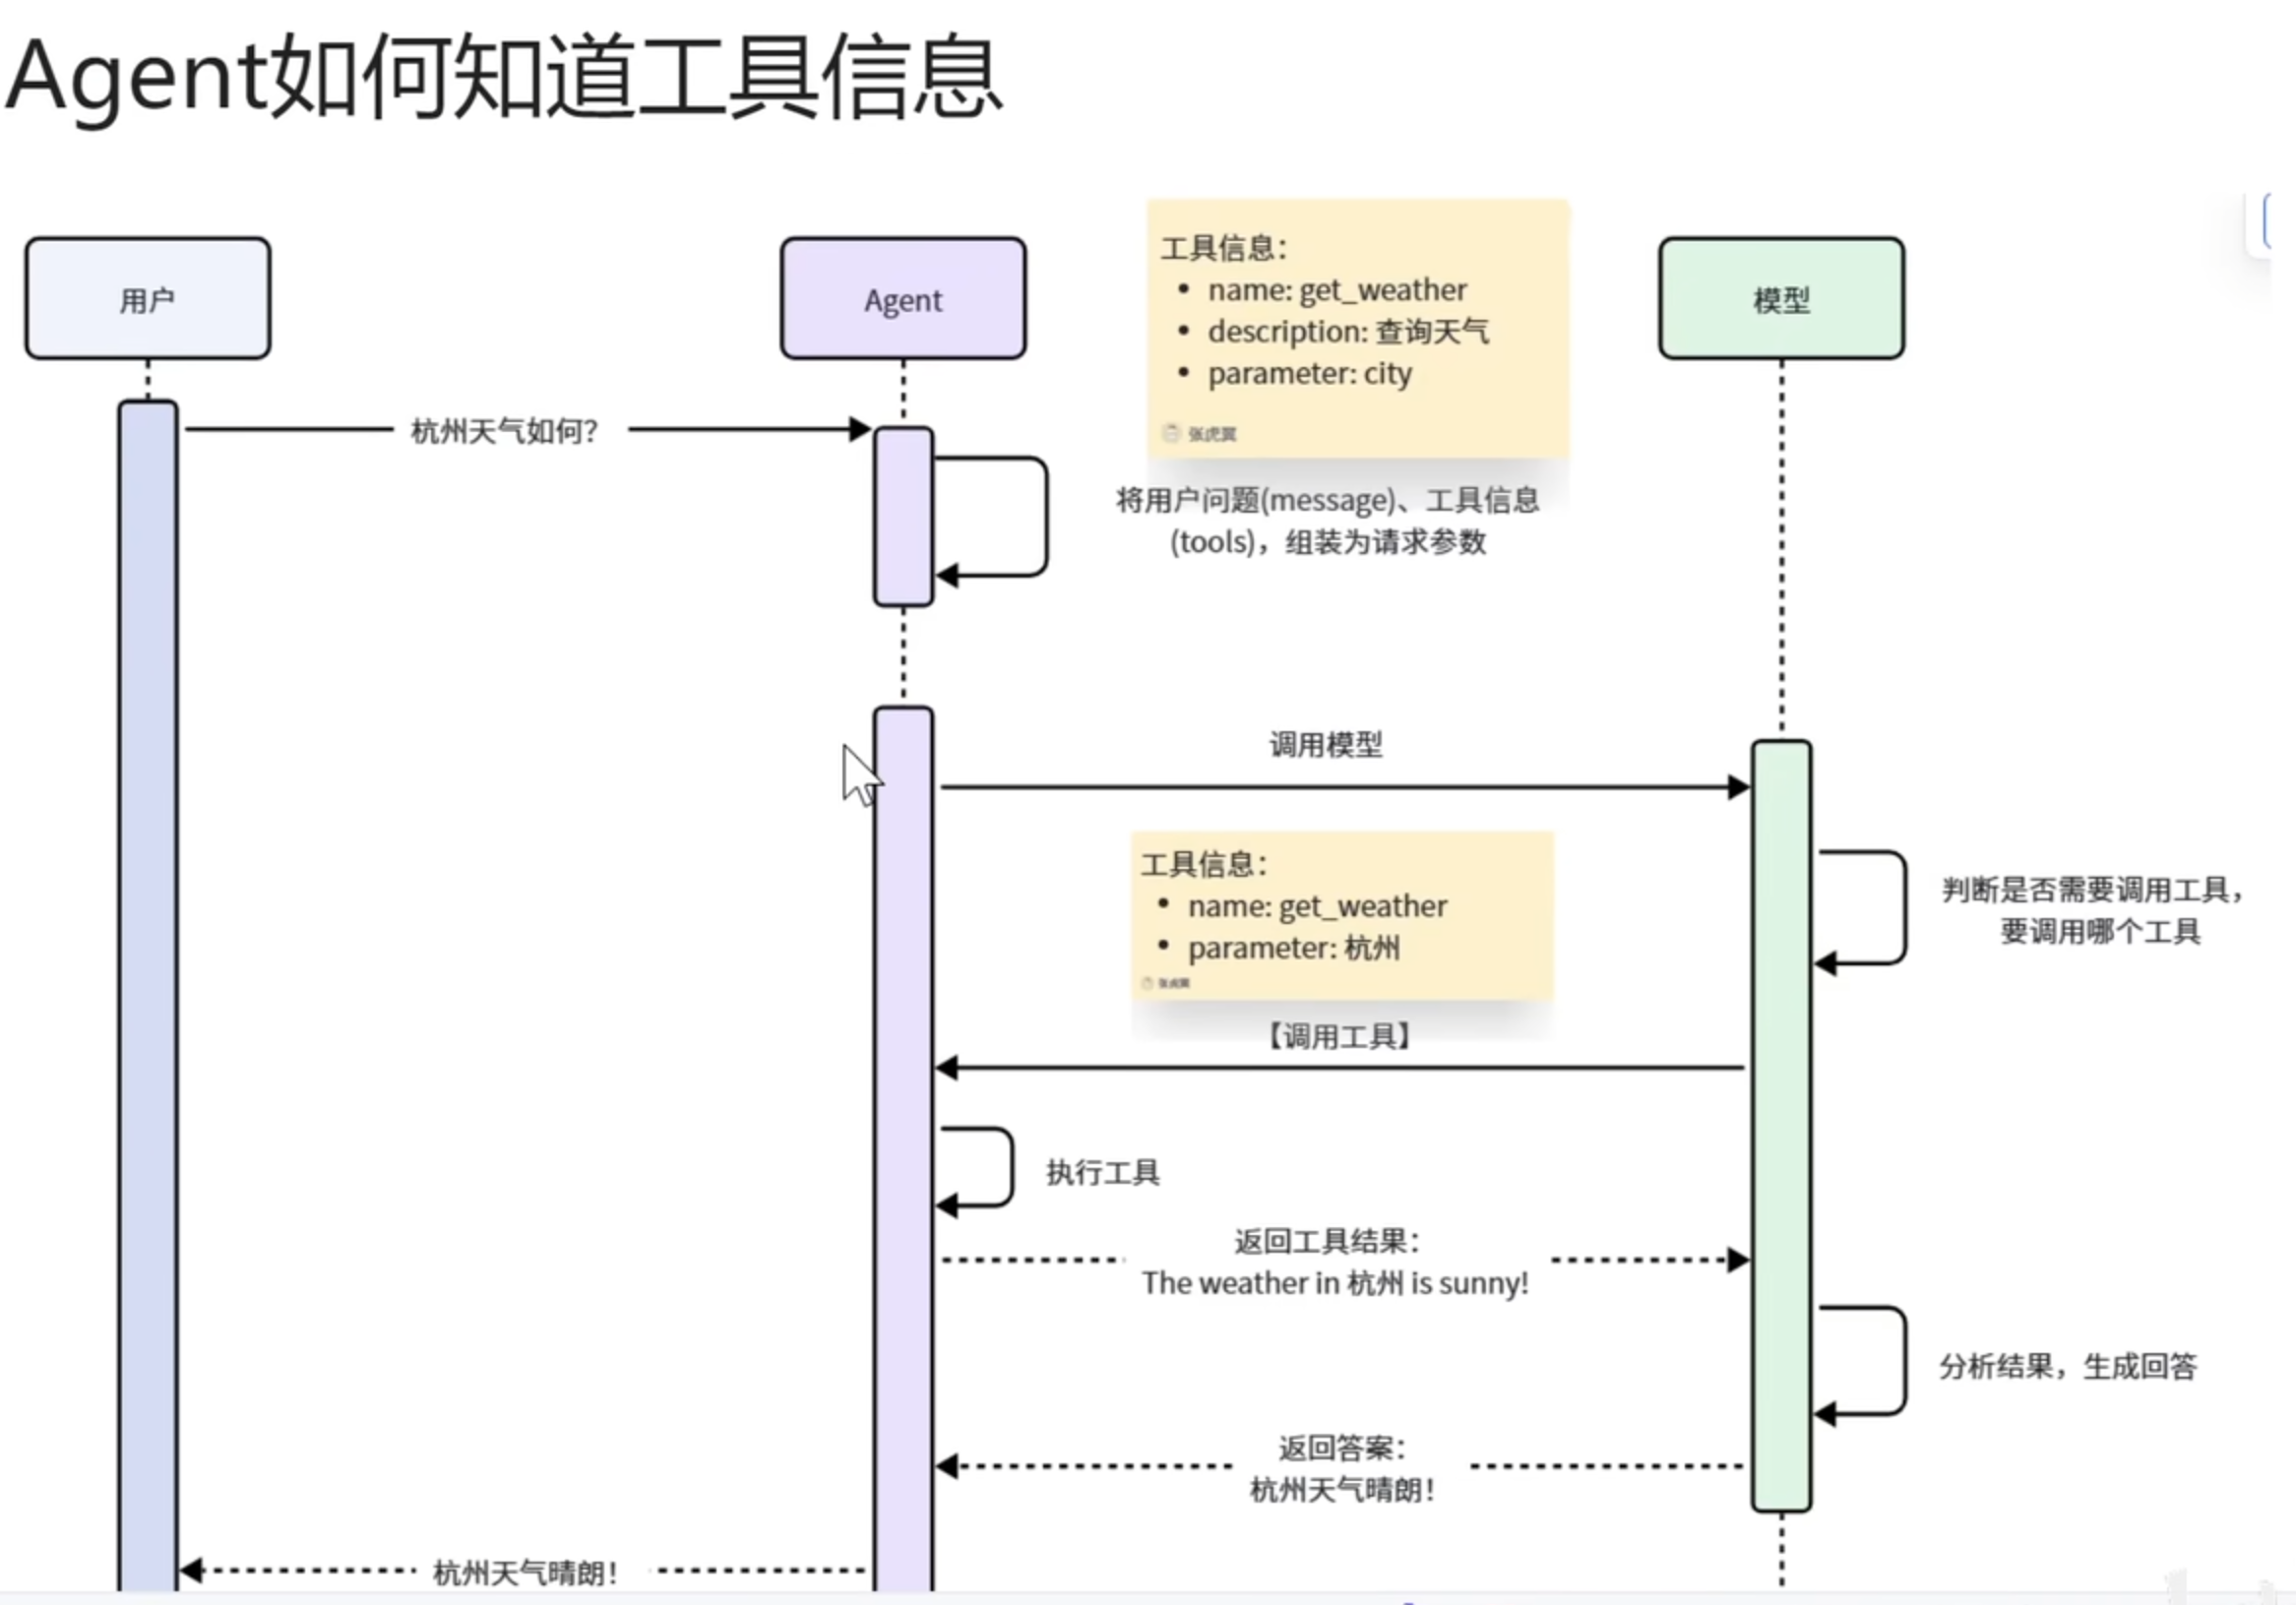